# Keystroke Dynamics Data Analysis Pipeline

This notebook implements a complete data analysis pipeline for keystroke authentication, including data loading, cleaning, feature engineering, SVM model training, and ROC curve visualization.

In [2]:
# Import Required Libraries
import sqlite3
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Step 1: Connect to database and load data
# Connect to the SQLite database
conn = sqlite3.connect('../project.db')

# Read the keystrokes table
df = pd.read_sql_query("SELECT user_id, dwell, flight FROM keystrokes", conn)
conn.close()

print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

Data loaded successfully!
Dataset shape: (868, 3)

First few rows:
   user_id  dwell  flight
0        1  184.6   936.2
1        1  190.8     0.5
2        1  175.7   408.4
3        1  151.8   792.2
4        1  119.8   112.1

Data types:
user_id      int64
dwell      float64
flight     float64
dtype: object

Missing values before cleaning:
user_id      0
dwell        0
flight     206
dtype: int64


In [4]:
# Step 2: Clean the data
# Drop rows with NULL values
df = df.dropna()

print(f"Data cleaned successfully!")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nData summary:")
print(df.describe())

Data cleaned successfully!
Dataset shape after cleaning: (662, 3)

Missing values after cleaning:
user_id    0
dwell      0
flight     0
dtype: int64

Data summary:
          user_id       dwell       flight
count  662.000000  662.000000   662.000000
mean     3.413897  159.220544   124.360574
std      1.579268   41.658203   180.655293
min      1.000000   16.000000  -119.300000
25%      2.000000  132.900000    20.500000
50%      3.000000  154.800000    61.150000
75%      5.000000  177.075000   215.725000
max      6.000000  344.000000  1290.400000


In [5]:
# Step 3: Define features (X) and target label (y)
# Features: dwell and flight columns
X = df[['dwell', 'flight']].values

# Target: User ID 1 is genuine user (class 1), all others are attackers (class 0)
y = (df['user_id'] == 1).astype(int).values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:")
print(f"Genuine users (class 1): {np.sum(y == 1)}")
print(f"Attackers (class 0): {np.sum(y == 0)}")
print(f"Class ratio: {np.sum(y == 1) / len(y):.4f}")

Features shape: (662, 2)
Target shape: (662,)

Class distribution:
Genuine users (class 1): 94
Attackers (class 0): 568
Class ratio: 0.1420


In [6]:
# Step 4: Split the data and train SVM model
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Train SVM classifier
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

print(f"\nSVM model trained successfully!")
print(f"Training accuracy: {svm_model.score(X_train, y_train):.4f}")
print(f"Testing accuracy: {svm_model.score(X_test, y_test):.4f}")

Training set size: 529
Testing set size: 133

SVM model trained successfully!
Training accuracy: 0.8941
Testing accuracy: 0.8496


ROC AUC Score: 0.8181


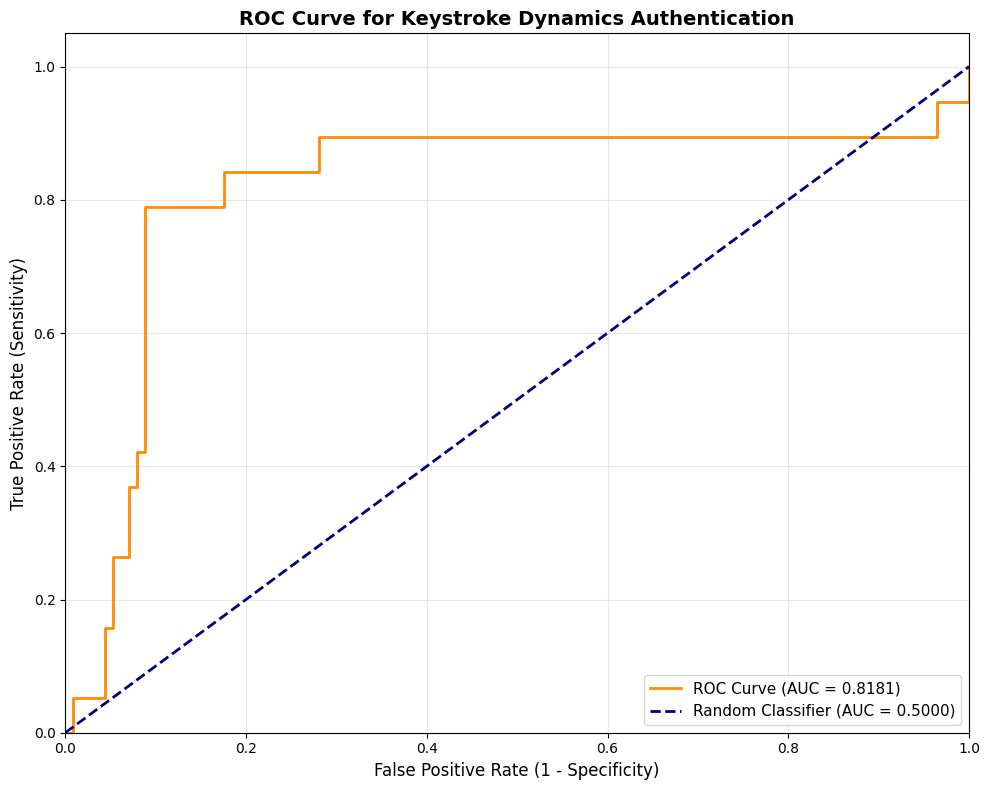


Model Performance Summary:
AUC Score: 0.8181
Test Set Accuracy: 0.8496


In [7]:
# Step 5: Generate ROC Curve with AUC Score
# Get probability predictions for the test set
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = auc(fpr, tpr)

print(f"ROC AUC Score: {auc_score:.4f}")

# Plot the ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve for Keystroke Dynamics Authentication', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel Performance Summary:")
print(f"{'='*50}")
print(f"AUC Score: {auc_score:.4f}")
print(f"Test Set Accuracy: {svm_model.score(X_test, y_test):.4f}")
print(f"{'='*50}")